In [7]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory

parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


The file already exist
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS


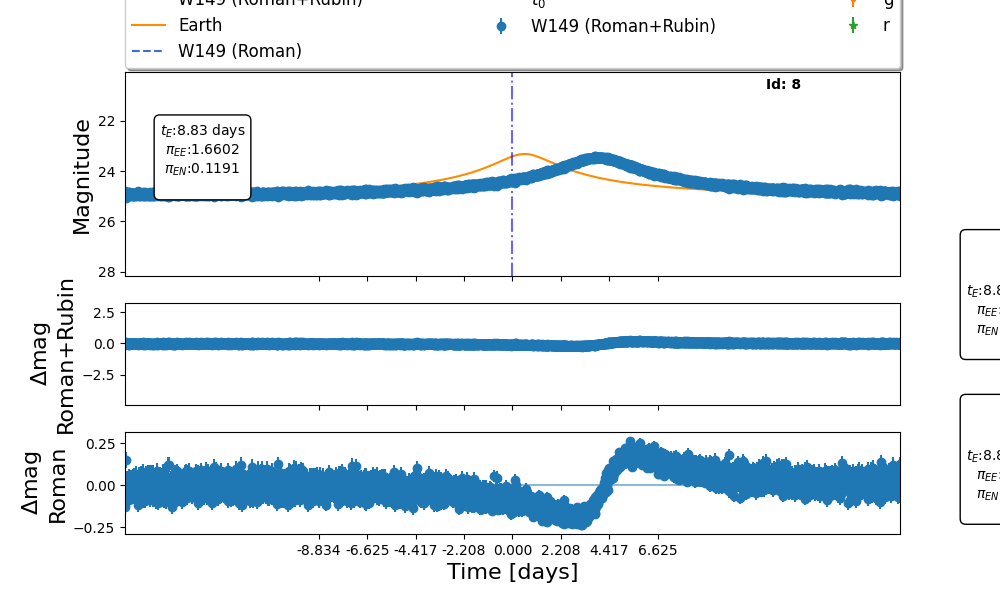

In [2]:

ssh = ssh_che()
#120
sources_array = [8]
model = "FSPL"

# download_data(sources, category)
nset = 1
# system_type = 'Planets_systems'
system_type = 'FFP'
path_run = f'/share/storage3/rubin/microlensing/romanrubin/RR2025/RGBTDS_set/{system_type}/'
path_save = f'/home/anibal/lightcurves/{system_type}_{nset}/'
if not os.path.exists(path_save):
    os.makedirs(path_save, exist_ok=True)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
    download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')


df_to_plot = create_df_to_plot(sources_array, model, path_save)
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

fig, axes = graph_maker_1plot(df_to_plot, model, True)
info, params, curves  = read_data(df_to_plot['path_event'].iloc[0])

plt.show()

In [3]:
# print(np.load(df_to_plot['path_fit_rr'].iloc[0],allow_pickle=True).item()['best_model'])

In [9]:
from fit_lc import fit_rubin_roman
algo='TRF'

Source = 1993
rango = 1
if True:
    lc_to_fit = {}
    for telo in curves:
        if not len(curves[telo]['mag'])==0:
            df = curves[telo][['time', 'mag','err_mag']].to_pandas()
            lc_to_fit[telo] = df.values
        else:
            lc_to_fit[telo] = []
    origin = info[2]

    fit_pspl, event_fit_pspl, pyLIMAmodel_pspl = fit_rubin_roman(Source,params, '/home/anibal/', '../ephemerides/Roman_positions.npy','FSPL',algo,origin, rango,
                               lc_to_fit["W149"],[],[],[],[],[],[])
    # lc_to_fit["u"], lc_to_fit["g"], lc_to_fit["r"],
                                           # lc_to_fit["i"], lc_to_fit["z"],lc_to_fit["y"])

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope Roman: SUCCESS
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2462952.8002751134, 0.1234227662223959, 8.83387410084196, 0.0009152812304247159, 0.11910598718816527, 1.6601638813948043, 5.155260057909116, 9.632387118197954]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2462952.8010010123)),
             ('u0', np.float64(0.12257738540682606)),
             ('tE', np.float64(8.84693865265855)),
             ('rho', np.float64(0.0008588459842727689)),
             ('piEN', np.float64(0.11989330135990518)),
             ('piEE', np.float64(1.6596075578897027)),
             ('fsource_Roman', np.float64(5.127049933627708)),
             ('ftotal_Roman', np.float64(9.632614900147816)),
             ('chi2', np.float64(51578.45167005908))])


In [9]:
from functions_roman_rubin import sim_fit
i =8
system_type = 'FFP'
model = 'FSPL'
algo = 'TRF'
path_TRILEGAL_set = '../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv'
path_GENULENS_set='../chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv'
path_to_save_model='../test_sim_fit/'
path_to_save_fit ='../test_sim_fit/'
path_ephemerides = '../ephemerides/Roman_positions.npy'
path_dataslice = '../asd'
fit_rr, pyLIMAmodel_rr, fit_roman, pyLIMAmodel_roman = sim_fit(i, system_type, model, algo, path_TRILEGAL_set, path_GENULENS_set, path_to_save_model, path_to_save_fit, path_ephemerides, path_dataslice)

{'W149': 24.9388, 'u': 31.649, 'g': 28.359, 'r': 26.928, 'i': 25.807, 'z': 25.266, 'y': 25.031}
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
A good event to fit
Criteria satisfied. Save the simulated light-curve.
Saving Simulation...
File saved: ../test_sim_fit/Event_8.h5
Start the 

Parallax(Full) estimated for the telescope Roman: SUCCESS


(<Figure size 750x750 with 2 Axes>, GridPlot(id='p1010', ...))

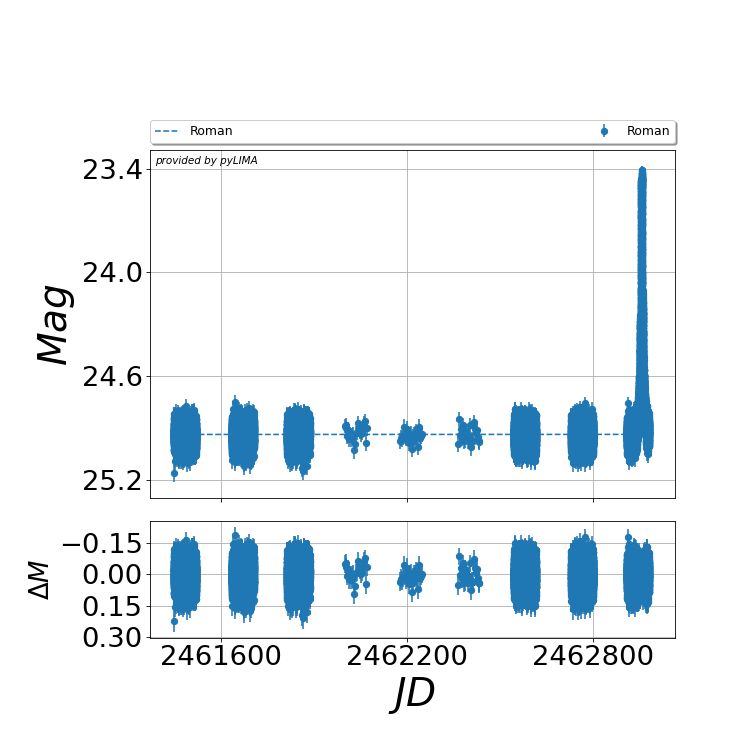

In [10]:
import pyLIMA_plots
from cycler import cycler
%matplotlib widget
colors1 = cycler(color=['purple', 'darkorange', 'forestgreen'])
# pyLIMA_plots.plot_lightcurves(pyLIMAmodel_pspl,fit_pspl.fit_results['best_model'])
pyLIMA_plots.plot_lightcurves(pyLIMAmodel_roman,fit_roman.fit_results['best_model'])#, MARKERS_COLORS=colors1)

In [12]:
# from functions_roman_rubin import sim_fit


i=8
Source = i

# if decision:
print("Criteria satisfied. Save the simulated light-curve.")

# save_sim(i, path_TRILEGAL_set, path_to_save_model, my_own_model, pyLIMA_parameters, event_params)
# if True:
lc_to_fit = {}
for telo in curves:
    if not len(curves[telo]['mag'])==0:
        df = curves[telo][['time', 'mag','err_mag']].to_pandas()
        lc_to_fit[telo] = df.values
    else:
        lc_to_fit[telo] = []
origin = info[2]
rango=1
print("Start the fit using Roman and Rubin data:")
fit_rr, event_fit_rr, pyLIMAmodel_rr = fit_rubin_roman(Source,params, '/home/anibal/', '../ephemerides/Roman_positions.npy','FSPL',algo,origin, rango,
                           lc_to_fit["W149"], lc_to_fit["u"], lc_to_fit["g"], lc_to_fit["r"],
                                       lc_to_fit["i"], lc_to_fit["z"],lc_to_fit["y"])
print("Start the fit using only the Roman data:")
fit_roman, event_fit_roman, pyLIMAmodel_roman = fit_rubin_roman(Source,params, '/home/anibal/', '../ephemerides/Roman_positions.npy','FSPL',algo,origin, rango,
                           lc_to_fit["W149"], [], [], [], [], [],[])



Criteria satisfied. Save the simulated light-curve.
Start the fit using Roman and Rubin data:
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope Roman: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2462927.503641659, -0.6916591956742613, 4.508653125421751, 0.0030611761995199363, -0.8291434216029543, 0.3304749643829016, 618.5157530947757, 743.4891135745241, 97.15052740554847, 183.76414011925698, 318.0370888884464, 433.92186220768883, 458.44680036770853, 592.776679527595, 371.5402361195038, 683.4064275832254, 417.86000875878284, 758.6403525266796]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2462927.5475097676)),
             ('u0'

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS


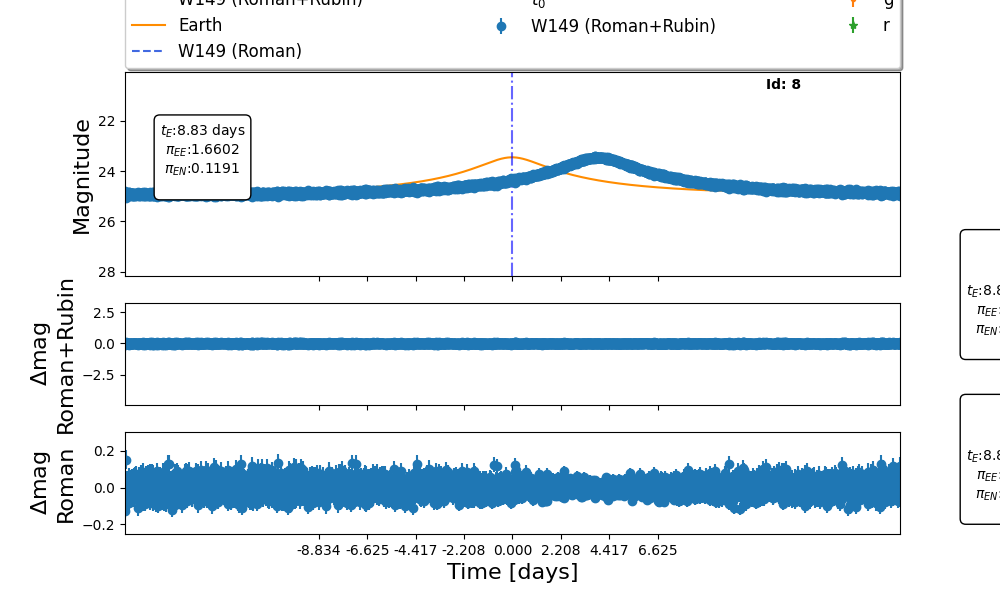

In [12]:

df_to_plot = create_df_to_plot([8], model, '../test_sim_fit/')
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

fig, axes = graph_maker_1plot(df_to_plot, model, True)
info, params, curves  = read_data(df_to_plot['path_event'].iloc[0])

plt.show()